In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:

n = 80
dt = 0.1

true_altitude = []

sensor_noise_std = 5.0

for i in range(n):
    if 0 <= i < 10:
        progress = (i - 0)/10
        #the estimate/progress = E_i/(E_i + E_m) 
        altitude = 0 + (20 - 0) * progress
    elif 10 <= i < 30:
        progress = (i - 10) / 20
        altitude = 20 + (90 - 20) * progress
    elif 30 <= i < 50:
        altitude = 90
    elif 50 <= i < 70:
        progress = (i - 50) / 20
        altitude = 90 + (20 - 90) * progress 
    else:
        progress = (i - 70) / 20
        altitude = 20 + (0 - 20) * progress

    true_altitude.append(altitude)

true_altitude = np.array(true_altitude)

measurements = true_altitude + np.random.normal(0, sensor_noise_std, n)

In [3]:
#state true value for now start on ground
x = np.array([[0.0], 
              [0.0]])
#initialize Identity matrix of size 2*2 and multiply by 1000 (uncertainty)
P = np.eye(2) * 1000
#state matrix remember: x_k = Ax_(k-1) + Bu_(k-1) + w_k
F = np.array([[1 , dt], 
              [0 , 1]])
H = np.array([[1.0 , 0.0]])
Q = np.eye(2) * 0.2
R = np.array([[sensor_noise_std]])
I = np.eye(2)

In [4]:
estimates = []
kalman_gains = []
covariances = []

In [5]:
for i in range(0, n):
    #initialize z as measurement at i and make it a 2x2 array
    z = np.array([[measurements[i]]])

    #@ is for array multiplication
    #np.transpose(F) = F.T
    x = F @ x
    P = F @ P @ F.T + Q

    #residual
    y = z - H @ x
    #total measurement uncertainty
    S = H @ P @ H.T + R
    #np.linalg.inv(S) calculates matrix inverse
    #Kalman Gain
    K = P @ H.T @ np.linalg.inv(S)
    
    x = x + K @ y

    #Joseph form covariance update
    P = (I - K @ H) @ P @ (I - K @ H).T + K @ R @ K.T

    #store
    estimates.append(float(x[0][0]))
    kalman_gains.append(float(K[0][0]))
    covariances.append(float(P[0][0]))

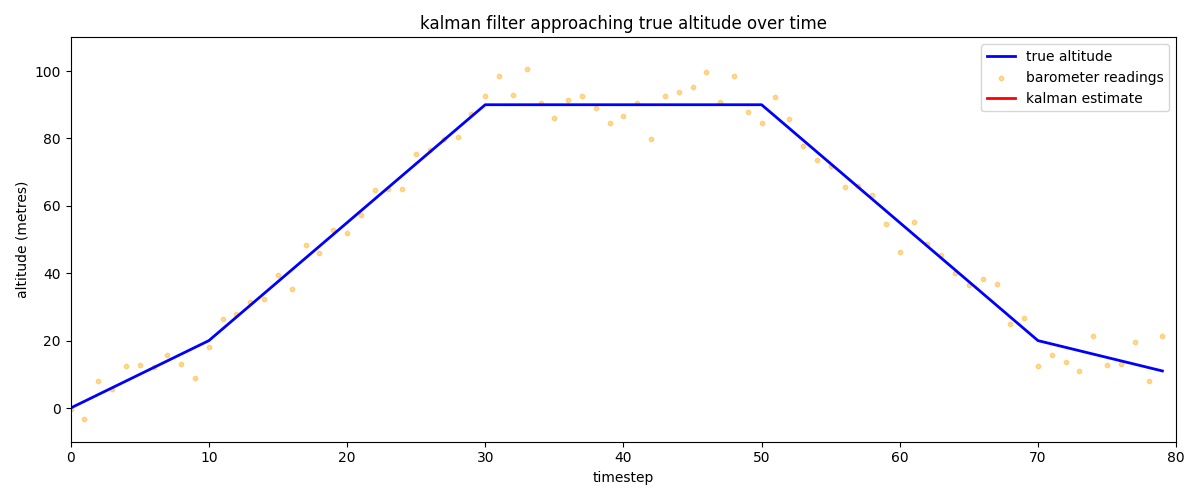

In [6]:
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(true_altitude, label='true altitude', linewidth=2, color='blue')
ax.scatter(range(n), measurements, label='barometer readings', s=10, alpha=0.4, color='orange')

kalman_line, = ax.plot([], [], label='kalman estimate', linewidth=2, color='red')

ax.set_xlim(0, n)
ax.set_ylim(-10, 110)
ax.set_xlabel('timestep')
ax.set_ylabel('altitude (metres)')
ax.set_title('kalman filter approaching true altitude over time')
ax.legend()

def update(frame):
    kalman_line.set_data(range(frame), estimates[:frame])
    return kalman_line,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=n,
    interval=80,
    blit=True
)

plt.tight_layout()
plt.show()